# Práctica #2 - Parte 1


### Resumen 
asopqsjj

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from statistics import mean
import scipy.io
from scipy.signal import find_peaks

#### Implementación de funciones
- Se crea una función rms, donde en el argumento se ingresa la señal de la cual se pretende obtener el valor.

In [2]:
y= 3*np.sin(2*np.pi*1*np.linspace(0, 1, 1000)) + 0.5*np.random.randn(1000)

# RMS de cada señal
def rms(signal):
    return np.sqrt(np.mean(signal**2))

RMS1 = rms(y)

print("RMS Voluntario 1:", RMS1)

RMS Voluntario 1: 2.207878430425312


- ahora se seleccione un ciclo cardiaco de la señal y se grafica. Luego calculamos el promedio, el valor RMS, la varianza y la desviación estándar del ciclo.

In [3]:
import numpy as np

promedio = np.mean(ciclos, axis=0)
varianza = np.var(ciclos, axis=0)
desviacion = np.std(ciclos, axis=0)

for i in range(len(promedio)):
    print(f"Ciclo {i+1}:")
    print(f"Promedio = {promedio[i]:.4f}")
    print(f"Varianza = {varianza[i]:.4f}")
    print(f"Desviacion estandar = {desviacion[i]:.4f}")


NameError: name 'ciclos' is not defined

In [4]:
datos = scipy.io.loadmat("signals.mat")
print(datos)
# 1. Extraer y forzar a que sean vectores de 1 dimensión (1D)
senal_original = np.squeeze(datos["ECG_asRecording"]) # Verifica que la llave sea la correcta
senal_filtrada = np.squeeze(datos["ECG_filtered"])

# 2. Obtener la cantidad exacta de puntos
N_original = len(senal_original)
N_filtrada = len(senal_filtrada)
Fs = 1024
# 3. Crear los vectores de tiempo 
t = np.arange(N_original) / Fs
t_filtrada = np.arange(N_filtrada) / Fs

# (Opcional) Imprimir las dimensiones para confirmar que ahora son iguales
print(f"Dimensión de t: {t.shape} | Dimensión de señal original: {senal_original.shape}")
print(f"Dimensión de t_filtrada: {t_filtrada.shape} | Dimensión de señal filtrada: {senal_filtrada.shape}")
print(f"La señal filtrada dura {N_filtrada} segundos")
print(f"La señal original dura {N_original} segundos")


{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Mon Apr 20 15:20:29 2015', '__version__': '1.0', '__globals__': [], 'Fs': array([[1024]], dtype=uint16), 'ECG_asRecording': array([[3904.31689453, 3939.203125  , 3976.00683594, ..., 4366.41064453,
        4365.31103516, 4370.91796875]], shape=(1, 30720)), 'ECG_filtered': array([[ 8.87103896e-03,  5.62737497e+01,  8.57077127e+01, ...,
        -1.20952610e+02, -1.31734356e+02, -1.32898021e+02]],
      shape=(1, 30720)), 'EMG_filtered1': array([[ 17.65905117,  19.41391578,  18.89666666, ..., 242.49414224,
        220.4135886 , 151.5810508 ]], shape=(1, 30721)), 'EMG_filtered2': array([[  21.1780547 ,  -79.82418538, -133.65960989, ..., -384.58994036,
        -539.9349533 , -772.65519631]], shape=(1, 30721)), 'EMG_asRecording1': array([[ 908.07531738,  903.17706299,  896.62982178, ..., 1433.91882324,
        1416.109375  , 1352.75012207]], shape=(1, 30721)), 'EMG_asRecording2': array([[-3109.97558594, -3231.01391602, -3302

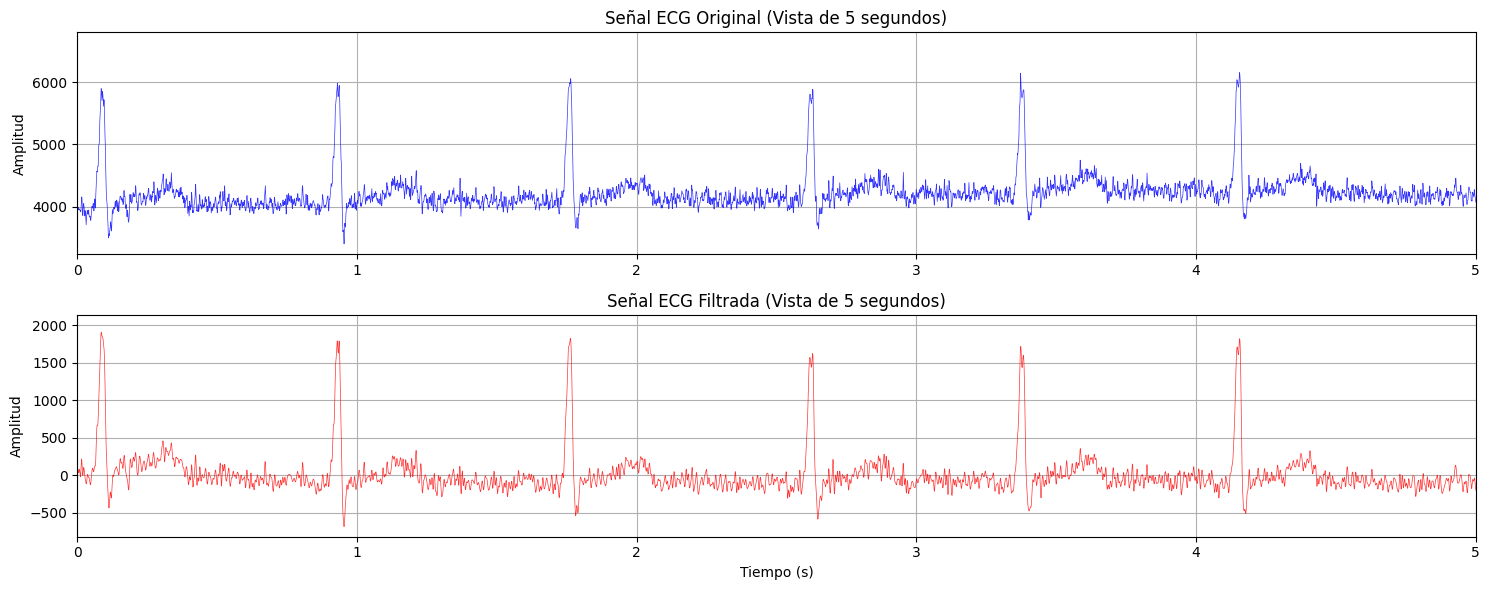

In [5]:
# Aumentar el ancho de la figura a 15 pulgadas
plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
# Añadir linewidth más delgado y alpha para transparencia
plt.plot(t, senal_original, color='blue', linewidth=0.5, alpha=0.8)
plt.title("Señal ECG Original (Vista de 5 segundos)")
plt.ylabel("Amplitud")
# Limitar el eje X para ver solo los primeros 5 segundos
plt.xlim(0, 5) 
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t_filtrada, senal_filtrada, color='red', linewidth=0.5, alpha=0.8)
plt.title("Señal ECG Filtrada (Vista de 5 segundos)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
# Limitar el eje X al mismo rango para poder compararlas directamente
plt.xlim(0, 5) 
plt.grid(True)

plt.tight_layout()
plt.show()

A partir de las dos señales podemos observar:

- Una amplitud corregida en la señal ECG filtrada, ya que para la original se encontraba en un eje desplazado (4000) y llega a picos de 6000, en cambio la señal filtrada esta centrada en cero, esto puede sugerir que se realizó un filtrado por pasa altas 

Métricas del Ciclo Cardíaco (Señal Original):
Promedio (Offset DC): 4198.21
Valor RMS: 4208.69
Varianza: 88096.03
Desviación Estándar: 296.81


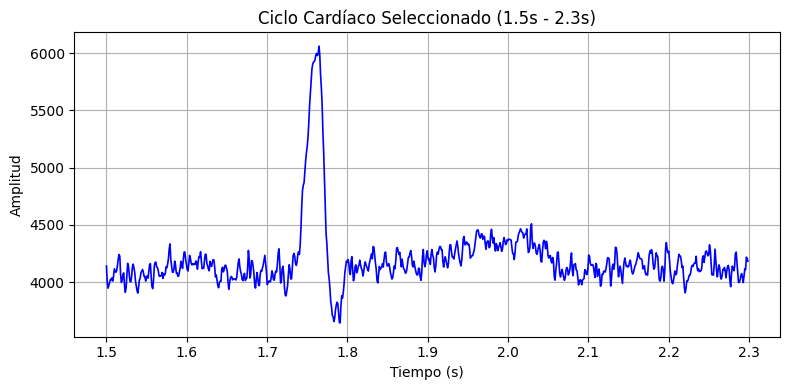

In [6]:

t_inicio = 1.5
t_fin = 2.3
Fs = 1024

idx_inicio = int(t_inicio * Fs)
idx_fin = int(t_fin * Fs)

ciclo_cardiaco = senal_original[idx_inicio:idx_fin]
t_ciclo = t[idx_inicio:idx_fin]

promedio = np.mean(ciclo_cardiaco)
valor_rms=rms(ciclo_cardiaco)
varianza = np.var(ciclo_cardiaco)
desviacion_std = np.std(ciclo_cardiaco)

print("Métricas del Ciclo Cardíaco (Señal Original):")
print(f"Promedio (Offset DC): {promedio:.2f}")
print(f"Valor RMS: {valor_rms:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Desviación Estándar: {desviacion_std:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(t_ciclo, ciclo_cardiaco, color='blue', linewidth=1.2)
plt.title("Ciclo Cardíaco Seleccionado (1.5s - 2.3s)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

- El promedio significa los valores de amplitud entre el total de muestras, asi las cosas, observamos como tiene un nivel DC elevado en aproximadamente 4200, esto se puede deber a el voltaje entre los electrodos y la piel.

- El valor RMS equivale a la potencia total de nuestra señal el valor de 4208 es similar al promedio de la señal, es decir, que no vemos el verdadero valor del RMS por la interferencia de la línea base.

- La varianza mide la dispersión de los datos respecto a la media, el valor (88096) es muy elevado, por que tenemos el pico que llega hasta una amplitud de 6000 el cual elevado al cuadrado y sumado con los otros datos deriva en este valor.  

- La desviación estándar es la raíz cuadrada de la varianza, nos entrega el valor mas acertado, pues no es afecto por el desplazamiento DC de la señal.


Métricas del Ciclo Cardíaco (Señal Original):
Promedio (Offset DC): -5.99
Valor RMS: 294.62
Varianza: 86764.69
Desviación Estándar: 294.56


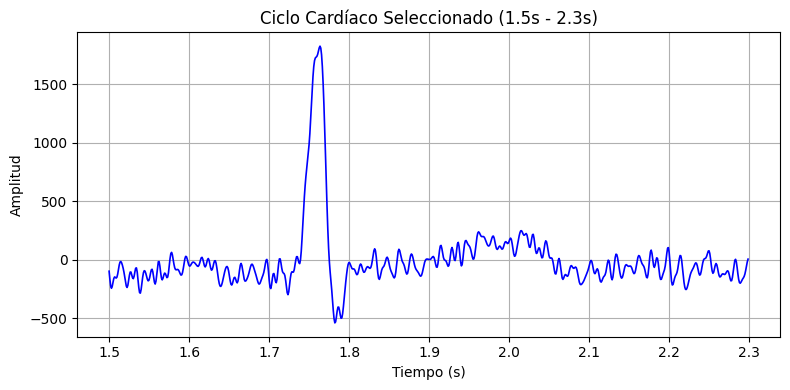

In [7]:
t_inicio = 1.5
t_fin = 2.3
Fs = 1024

idx_inicio = int(t_inicio * Fs)
idx_fin = int(t_fin * Fs)

ciclo_cardiaco = senal_filtrada[idx_inicio:idx_fin]
t_ciclo = t[idx_inicio:idx_fin]

promedio = np.mean(ciclo_cardiaco)
valor_rms=rms(ciclo_cardiaco)
varianza = np.var(ciclo_cardiaco)
desviacion_std = np.std(ciclo_cardiaco)

print("Métricas del Ciclo Cardíaco (Señal Original):")
print(f"Promedio (Offset DC): {promedio:.2f}")
print(f"Valor RMS: {valor_rms:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Desviación Estándar: {desviacion_std:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(t_ciclo, ciclo_cardiaco, color='blue', linewidth=1.2)
plt.title("Ciclo Cardíaco Seleccionado (1.5s - 2.3s)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

## Comparación:

- Se puede observar como disminuyó el valor promedio para la señal filtrada, pasó de 4198 a -6, esto gracias a la corrección del nivel DC que movió la señal a 0 en el eje X.

- En el valor RMS también se observa un cambio representativo pasando de 4208.69 a 294.62 en la señal filtrada, esto ocurre por la corrección del nivel DC, llevando a que la señal tenga una menor amplitud, este nuevo valor representa la energía electrica producida por el ciclo cardiaco.

- La varianza no se ve afectada, no hay mayores cambios, pues los datos sean filtrados o no estan igual de dispersos.

- La desviación estándar como dijimos mide la amplitud de la señal, así que se supone no debe cambiar, y así pasó, por consiguiente nos mide el valor real del complejo QRS antes y después de filtrada.

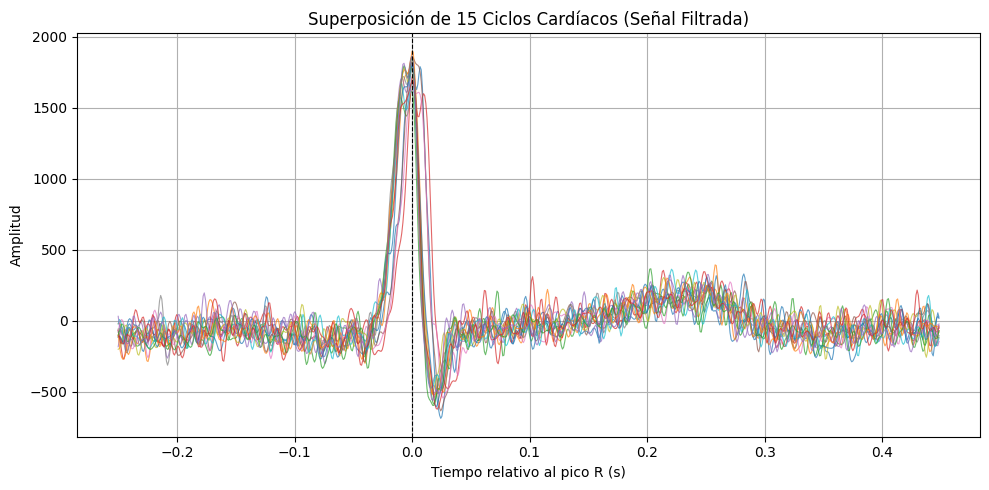

Análisis de los 15 Ciclos Cardíacos:
Ciclo    | Promedio     | Varianza
-----------------------------------
1        | 16.37        | 99799.75
2        | 7.29         | 96982.76
3        | 0.80         | 86273.30
4        | 21.78        | 88046.29
5        | 20.32        | 98521.65
6        | 23.28        | 100900.99
7        | 14.08        | 83759.12
8        | 26.70        | 95854.29
9        | 36.38        | 94434.78
10       | 11.94        | 87127.75
11       | 10.20        | 93089.44
12       | 27.74        | 102432.25
13       | 6.19         | 104155.52
14       | 26.21        | 88380.59
15       | 21.97        | 99264.76


In [13]:
# 1. Detectar los picos R en la señal filtrada
distancia_minima = int(0.6 * Fs)
picos, _ = find_peaks(senal_filtrada, height=1000, distance=distancia_minima)

# Definir la ventana del ciclo
vent_antes = int(0.25 * Fs)
vent_despues = int(0.45 * Fs)

# CORRECCIÓN: Filtrar los picos para asegurar que tengan espacio suficiente a los lados
picos_validos = []
for p in picos:
    if (p - vent_antes >= 0) and (p + vent_despues < len(senal_filtrada)):
        picos_validos.append(p)

# Seleccionar exactamente 15 picos válidos
picos_validos = picos_validos[:15]

promedios = []
varianzas = []

# 2. Graficar los ciclos superpuestos
plt.figure(figsize=(10, 5))
t_relativo = np.arange(-vent_antes, vent_despues) / Fs

for i, pico in enumerate(picos_validos): # Asegúrate de usar picos_validos aquí
    # Extraer el fragmento del ciclo
    ciclo = senal_filtrada[pico - vent_antes : pico + vent_despues]
    
    # Calcular métricas
    promedios.append(np.mean(ciclo))
    varianzas.append(np.var(ciclo))
    
    # Graficar con transparencia
    plt.plot(t_relativo, ciclo, linewidth=0.8, alpha=0.7)

# ... (El resto del código de la gráfica y los prints se mantiene igual) ...

plt.title("Superposición de 15 Ciclos Cardíacos (Señal Filtrada)")
plt.xlabel("Tiempo relativo al pico R (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8) # Marcar el pico R
plt.tight_layout()
plt.show()

# 3. Imprimir la tabla de resultados estadísticos
print("Análisis de los 15 Ciclos Cardíacos:")
print(f"{'Ciclo':<8} | {'Promedio':<12} | {'Varianza'}")
print("-" * 35)
for i in range(15):
    print(f"{i+1:<8} | {promedios[i]:<12.2f} | {varianzas[i]:.2f}")